# 2.2-2.7. Stations, pies, arrows, hashes, ellipses, circular arrows

Recreates the README's `create_stations`/`create_pies`/`create_arrow`/
`create_hashes`/`create_ellipse`/`create_circular_arrow` figures. Uses
`load_asds()`/`load_coastline()` (live) in a couple of cells where the R
tutorial itself does; everything else runs off the bundled example
datasets.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import BoundaryNorm, ListedColormap
from shapely import segmentize
from shapely.geometry import Polygon, box

import ccamlrgis as cg
import ccamlrgis.plot as cgplot
from ccamlrgis import datasets

depth_cmap = ListedColormap(cg.DEPTH_COLS)
depth_norm = BoundaryNorm(cg.DEPTH_CUTS, depth_cmap.N)
coast = datasets.load_example("Coast")
coast_all = coast[coast["ID"] == "All"]
bathy_small = cg.small_bathy()


def longest_circumpolar_isobath(bathy_da, level=-1000):
    """Longest closed contour line at `level`, as an (N, 2) array of (x, y)
    in the CCAMLR CRS -- the Python equivalent of the R tutorial's
    `as.contour(SmallBathy(), levels=...)` + keep-longest-line steps."""
    arr = bathy_da.to_numpy()
    xs = bathy_da.x.to_numpy()
    ys = bathy_da.y.to_numpy()
    fig_tmp, ax_tmp = plt.subplots()
    cs = ax_tmp.contour(xs, ys, arr, levels=[level])
    segs = cs.allsegs[0]
    plt.close(fig_tmp)
    lengths = [np.hypot(np.diff(s[:, 0]), np.diff(s[:, 1])).sum() for s in segs]
    return segs[int(np.argmax(lengths))]

## 2.2. Create Stations

First, create a polygon within which stations will be created.

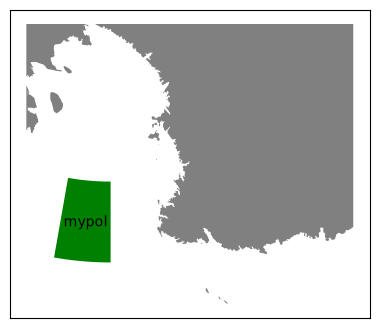

In [2]:
my_poly_df = pd.DataFrame({
    "Name": ["mypol"] * 4,
    "Latitude": [-75, -75, -70, -70],
    "Longitude": [-170, -180, -180, -170],
})
my_poly = cg.create_polys(my_poly_df, densify=True)
coast_881 = coast[coast["ID"] == "88.1"]

fig, ax = plt.subplots(figsize=(8, 4))
cgplot.basemap(ax=ax)
coast_881.plot(ax=ax, color="grey")
my_poly.plot(ax=ax, color="green")
for _, row in my_poly.iterrows():
    ax.annotate(row["ID"], (row["Labx"], row["Laby"]), ha="center", va="center")
plt.show()

In [3]:
# optional: crop the bathymetry raster to match the extent of the polygon
bathy_crop = bathy_small.rio.clip_box(*my_poly.total_bounds)
my_cols = cg.add_colour([-10000, 10000], cuts=[-2000, -1500, -1000, -550], cols=["blue", "cyan"])
strata_cmap = ListedColormap(my_cols["cols"])
strata_norm = BoundaryNorm(my_cols["cuts"], strata_cmap.N)

Example 1. Set numbers of stations, no distance constraint:

/Users/zephyrsylvester/miniforge3/envs/ccamlrgis-py/lib/python3.11/site-packages/rasterio/features.py:129: RuntimeWarning: DeprecationWarning: 'Memory' driver is deprecated since GDAL 3.11. Use 'MEM' onwards. Further messages of this type will be suppressed.
  yield from _shapes(source, mask, connectivity, transform)


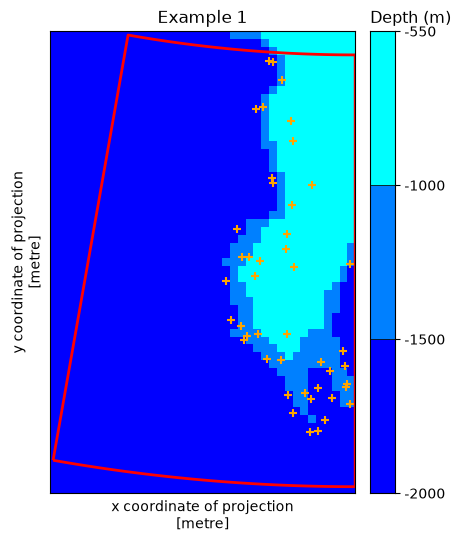

In [4]:
stations1 = cg.create_stations(my_poly, bathy_crop, depths=[-2000, -1500, -1000, -550], n=[20, 15, 10], seed=1)

fig, ax = plt.subplots(figsize=(8, 6))
cgplot.basemap(ax=ax)
bathy_crop.plot(ax=ax, cmap=strata_cmap, norm=strata_norm, add_colorbar=False)
cgplot.add_colour_scale(ax=ax, cuts=my_cols["cuts"], cols=my_cols["cols"], size="8%")
my_poly.boundary.plot(ax=ax, edgecolor="red", linewidth=2)
stations1.plot(ax=ax, marker="+", color="orange")
ax.set_title("Example 1")
plt.show()

Example 2. Set numbers of stations, with distance constraint:

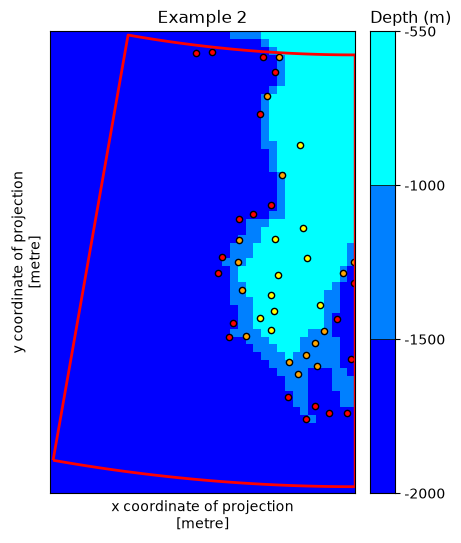

In [5]:
stations2 = cg.create_stations(
    my_poly, bathy_crop, depths=[-2000, -1500, -1000, -550], n=[20, 15, 10], dist=10, seed=1
)

fig, ax = plt.subplots(figsize=(8, 6))
cgplot.basemap(ax=ax)
bathy_crop.plot(ax=ax, cmap=strata_cmap, norm=strata_norm, add_colorbar=False)
cgplot.add_colour_scale(ax=ax, cuts=my_cols["cuts"], cols=my_cols["cols"], size="8%")
my_poly.boundary.plot(ax=ax, edgecolor="red", linewidth=2)
for stratum, colour in [("1000-550", "yellow"), ("1500-1000", "orange"), ("2000-1500", "red")]:
    stations2[stations2["Stratum"] == stratum].plot(ax=ax, marker="o", color=colour, edgecolor="black", markersize=20)
ax.set_title("Example 2")
plt.show()

Example 3. Automatic numbers of stations, with distance constraint:

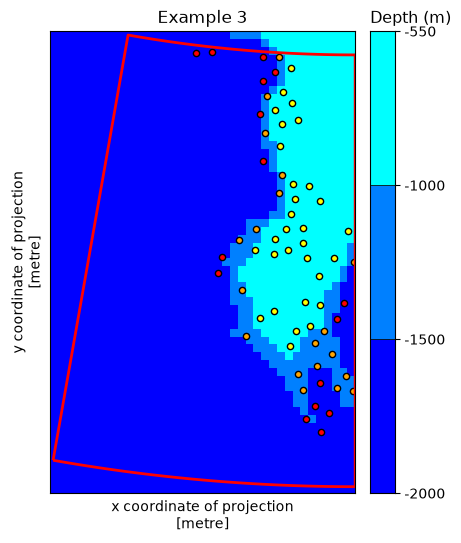

In [6]:
stations3 = cg.create_stations(
    my_poly, bathy_crop, depths=[-2000, -1500, -1000, -550], n_auto=30, dist=10, seed=1
)

fig, ax = plt.subplots(figsize=(8, 6))
cgplot.basemap(ax=ax)
bathy_crop.plot(ax=ax, cmap=strata_cmap, norm=strata_norm, add_colorbar=False)
cgplot.add_colour_scale(ax=ax, cuts=my_cols["cuts"], cols=my_cols["cols"], size="8%")
my_poly.boundary.plot(ax=ax, edgecolor="red", linewidth=2)
for stratum, colour in [("1000-550", "yellow"), ("1500-1000", "orange"), ("2000-1500", "red")]:
    stations3[stations3["Stratum"] == stratum].plot(ax=ax, marker="o", color=colour, edgecolor="black", markersize=20)
ax.set_title("Example 3")
plt.show()

## 2.3. Create pies

`add_pie_legend` (this port) only draws the classes legend, not R's
optional pie-size legend (`SizeTitle=`) -- a cosmetic simplification, see
`docs/porting_notes.md`.

In [7]:
pie_data = datasets.load_example("PieData")
pie_data2 = datasets.load_example("PieData2")

asds = cg.load_asds()
s486 = asds[asds["GAR_Short_Label"] == "486"]
bathy_486 = bathy_small.rio.clip_box(*s486.total_bounds)
coast_486 = coast[coast["ID"] == "48.6"]

Example 1. Pies of constant size, all classes displayed:

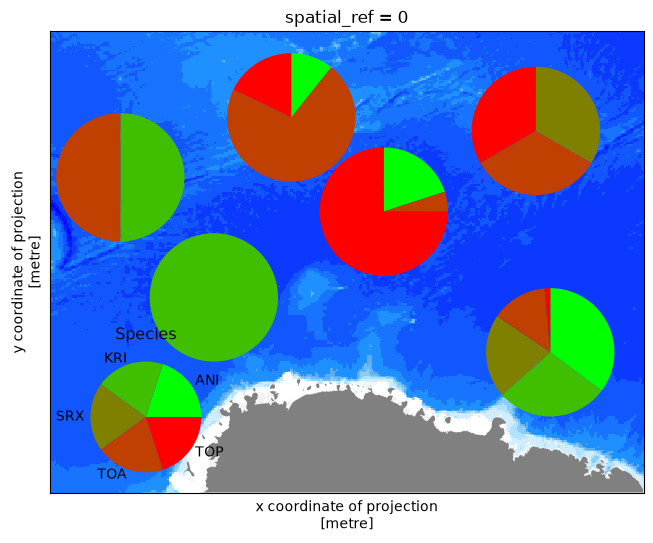

In [8]:
fig, ax = plt.subplots(figsize=(8, 6))
cgplot.basemap(ax=ax)
bathy_486.plot(ax=ax, cmap=depth_cmap, norm=depth_norm, add_colorbar=False)
coast_486.plot(ax=ax, color="grey", linewidth=0.01)
pies = cg.create_pies(pie_data, names_in=["Lat", "Lon", "Sp", "N"], size=50)
pies.plot(ax=ax, color=list(pies["col"]))
cgplot.add_pie_legend(ax=ax, pies=pies, title="Species")
plt.show()

Example 2. Pies of constant size, selected classes displayed:

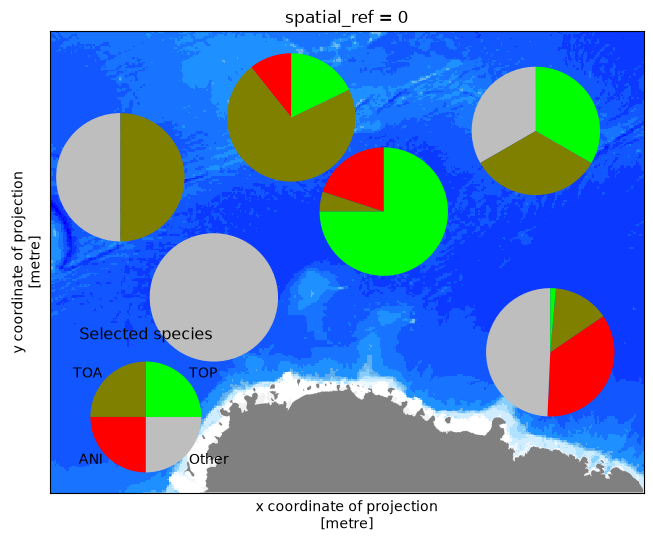

In [9]:
fig, ax = plt.subplots(figsize=(8, 6))
cgplot.basemap(ax=ax)
bathy_486.plot(ax=ax, cmap=depth_cmap, norm=depth_norm, add_colorbar=False)
coast_486.plot(ax=ax, color="grey", linewidth=0.01)
pies = cg.create_pies(pie_data, names_in=["Lat", "Lon", "Sp", "N"], size=50, classes=["TOP", "TOA", "ANI"])
pies.plot(ax=ax, color=list(pies["col"]))
cgplot.add_pie_legend(ax=ax, pies=pies, title="Selected species")
plt.show()

Example 3. Pies of constant size, proportions below 25% are grouped in
an 'Other' class:

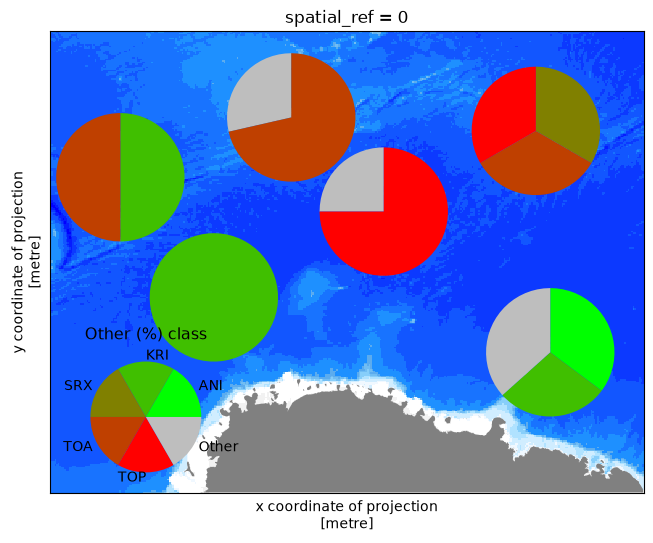

In [10]:
fig, ax = plt.subplots(figsize=(8, 6))
cgplot.basemap(ax=ax)
bathy_486.plot(ax=ax, cmap=depth_cmap, norm=depth_norm, add_colorbar=False)
coast_486.plot(ax=ax, color="grey", linewidth=0.01)
pies = cg.create_pies(pie_data, names_in=["Lat", "Lon", "Sp", "N"], size=50, other=25)
pies.plot(ax=ax, color=list(pies["col"]))
cgplot.add_pie_legend(ax=ax, pies=pies, title="Other (%) class")
plt.show()

Example 4. Pies of variable size (area proportional to 'Catch'), all
classes displayed:

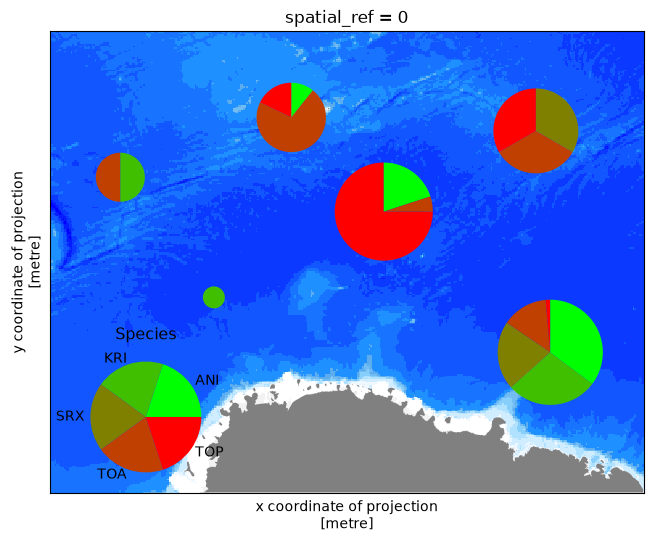

In [11]:
fig, ax = plt.subplots(figsize=(8, 6))
cgplot.basemap(ax=ax)
bathy_486.plot(ax=ax, cmap=depth_cmap, norm=depth_norm, add_colorbar=False)
coast_486.plot(ax=ax, color="grey", linewidth=0.01)
pies = cg.create_pies(pie_data, names_in=["Lat", "Lon", "Sp", "N"], size=18, size_var="Catch")
pies.plot(ax=ax, color=list(pies["col"]))
cgplot.add_pie_legend(ax=ax, pies=pies, title="Species")
plt.show()

Example 5. Same pies, legend placed elsewhere on the map:

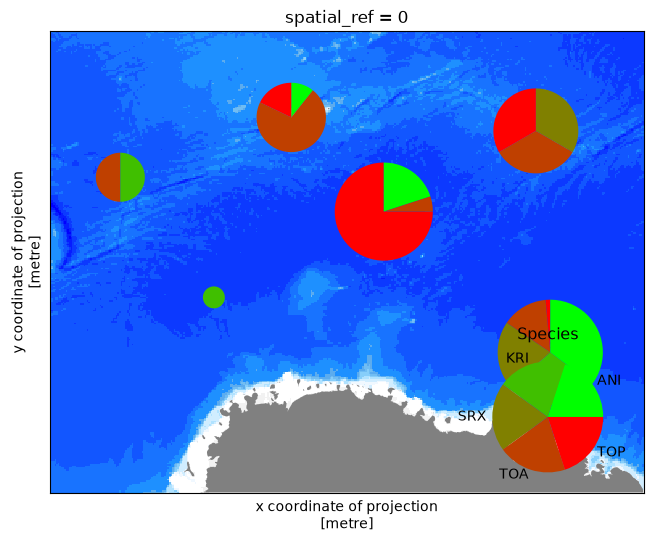

In [12]:
fig, ax = plt.subplots(figsize=(8, 6))
cgplot.basemap(ax=ax)
bathy_486.plot(ax=ax, cmap=depth_cmap, norm=depth_norm, add_colorbar=False)
coast_486.plot(ax=ax, color="grey", linewidth=0.01)
pies = cg.create_pies(pie_data, names_in=["Lat", "Lon", "Sp", "N"], size=18, size_var="Catch")
pies.plot(ax=ax, color=list(pies["col"]))
cgplot.add_pie_legend(ax=ax, pies=pies, title="Species", loc="lower right")
plt.show()

Example 6. Pies of constant size, all classes displayed. Too many pies (see next example for a fix):

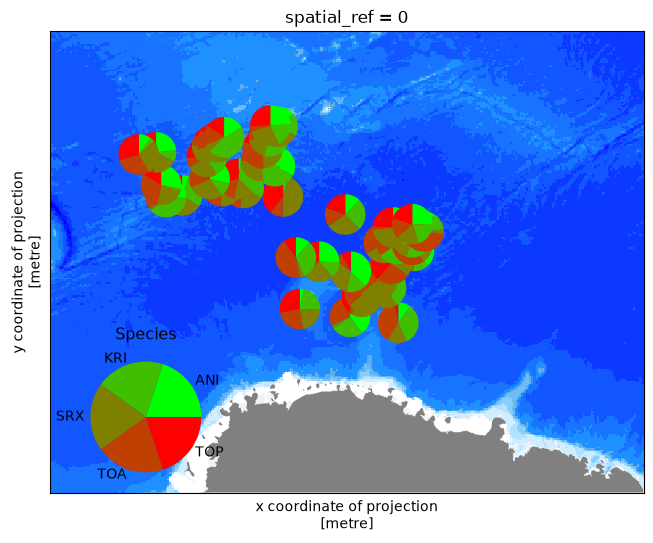

In [13]:
fig, ax = plt.subplots(figsize=(8, 6))
cgplot.basemap(ax=ax)
bathy_486.plot(ax=ax, cmap=depth_cmap, norm=depth_norm, add_colorbar=False)
coast_486.plot(ax=ax, color="grey", linewidth=0.01)
pies = cg.create_pies(pie_data2, names_in=["Lat", "Lon", "Sp", "N"], size=5)
pies.plot(ax=ax, color=list(pies["col"]))
cgplot.add_pie_legend(ax=ax, pies=pies, title="Species")
plt.show()

Example 7. Same data, gridded locations (numerical variables are summed
for each grid point):

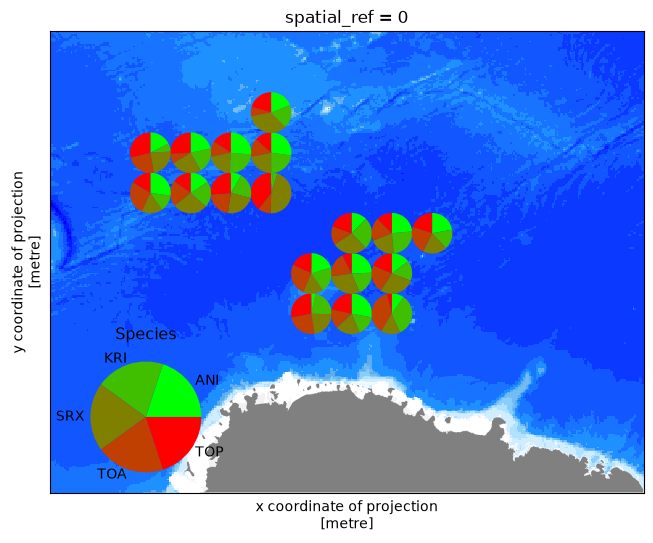

In [14]:
fig, ax = plt.subplots(figsize=(8, 6))
cgplot.basemap(ax=ax)
bathy_486.plot(ax=ax, cmap=depth_cmap, norm=depth_norm, add_colorbar=False)
coast_486.plot(ax=ax, color="grey", linewidth=0.01)
pies = cg.create_pies(pie_data2, names_in=["Lat", "Lon", "Sp", "N"], size=5, grid_km=250)
pies.plot(ax=ax, color=list(pies["col"]))
cgplot.add_pie_legend(ax=ax, pies=pies, title="Species")
plt.show()

Example 8. Variable size (area proportional to 'Catch'), gridded locations:

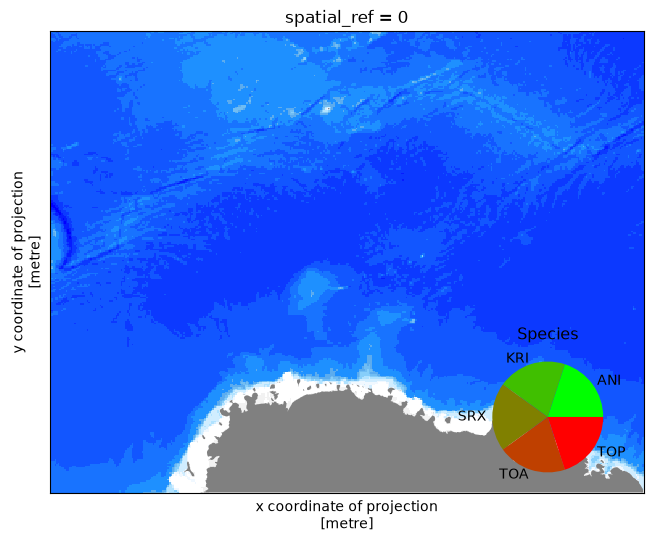

In [15]:
fig, ax = plt.subplots(figsize=(8, 6))
cgplot.basemap(ax=ax)
bathy_486.plot(ax=ax, cmap=depth_cmap, norm=depth_norm, add_colorbar=False)
coast_486.plot(ax=ax, color="grey", linewidth=0.01)
pies = cg.create_pies(pie_data2, names_in=["Lat", "Lon", "Sp", "N"], size=3, grid_km=250, size_var="Catch")
pies.plot(ax=ax, color=list(pies["col"]))
cgplot.add_pie_legend(ax=ax, pies=pies, title="Species", loc="lower right")
plt.show()

## 2.4. Create Arrow\n\nExamples 1-4:

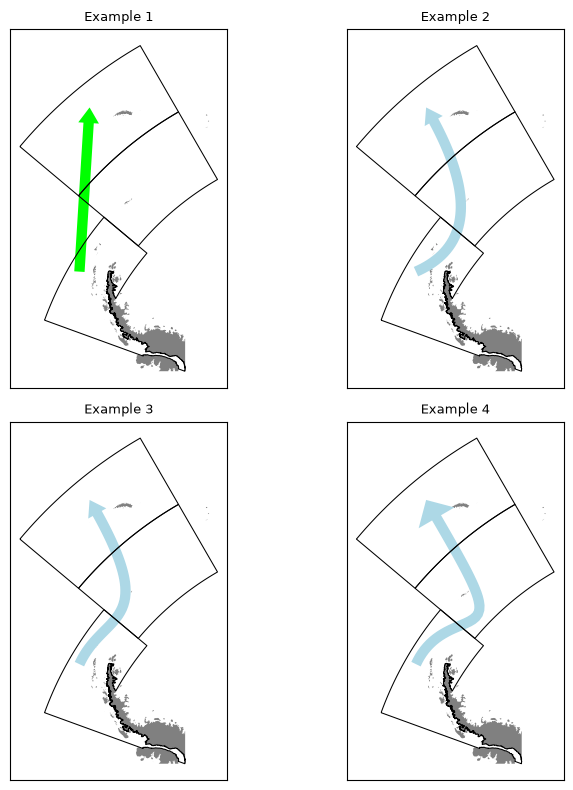

In [16]:
asds_481_3 = asds[asds["GAR_Short_Label"].isin(["481", "482", "483"])]
coast_481_3 = coast[coast["ID"].isin(["48.1", "48.2", "48.3"])]

arrow_specs = [
    (pd.DataFrame({"lat": [-61, -52], "lon": [-60, -40]}), {}),
    (pd.DataFrame({"lat": [-61, -65, -52], "lon": [-60, -45, -40]}), {"colour": "lightblue"}),
    (pd.DataFrame({"lat": [-61, -60, -65, -52], "lon": [-60, -50, -45, -40]}), {"colour": "lightblue"}),
    (
        pd.DataFrame({"lat": [-61, -60, -65, -52], "lon": [-60, -50, -45, -40], "w": [1, 1, 2, 1]}),
        {"colour": "lightblue", "hlength": 20, "hwidth": 20},
    ),
]

fig, axes = plt.subplots(2, 2, figsize=(8, 8))
for ax, (inp, kwargs), title in zip(axes.flat, arrow_specs, [f"Example {i}" for i in range(1, 5)]):
    arrow = cg.create_arrow(inp, **kwargs)
    cgplot.basemap(ax=ax)
    asds_481_3.boundary.plot(ax=ax, color="black", linewidth=0.75)
    coast_481_3.plot(ax=ax, color="grey")
    arrow.plot(ax=ax, color=list(arrow["col"]))
    ax.set_title(title, fontsize=9)
fig.tight_layout()
plt.show()

Examples 5-8 (dashed arrows):

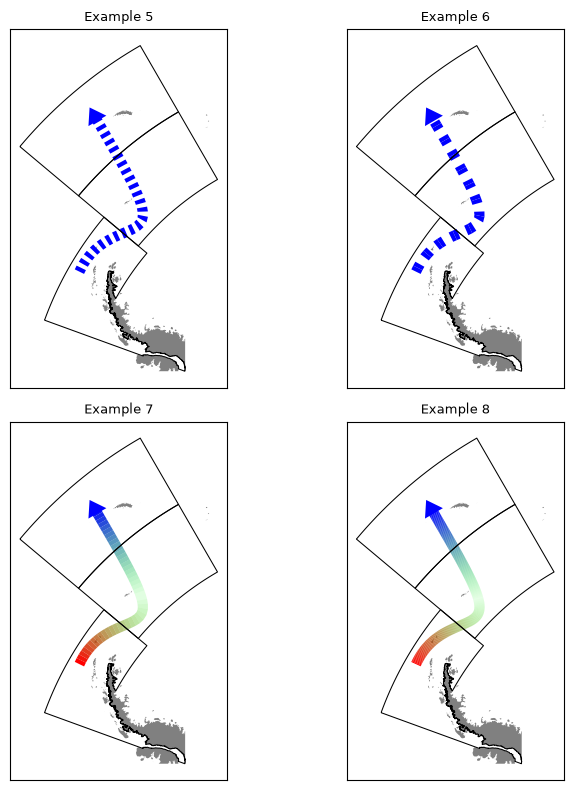

In [17]:
inp = pd.DataFrame({"lat": [-61, -60, -65, -52], "lon": [-60, -50, -45, -40], "w": [1, 1, 2, 1]})
dashed_specs = [
    {"colour": "blue", "arrow_type": "dashed", "dlength": 1},
    {"colour": "blue", "arrow_type": "dashed", "dlength": 2},
    {"colour": ["red", "green", "blue"], "transparency": [0, 0.9, 0], "arrow_type": "dashed", "dlength": 0},
    {
        "n_points": 200,
        "colour": ["red", "green", "blue"],
        "transparency": [0, 0.9, 0],
        "arrow_type": "dashed",
        "dlength": 0,
    },
]

fig, axes = plt.subplots(2, 2, figsize=(8, 8))
for ax, kwargs, title in zip(axes.flat, dashed_specs, [f"Example {i}" for i in range(5, 9)]):
    arrow = cg.create_arrow(inp, **kwargs)
    cgplot.basemap(ax=ax)
    asds_481_3.boundary.plot(ax=ax, color="black", linewidth=0.75)
    coast_481_3.plot(ax=ax, color="grey")
    arrow.plot(ax=ax, color=list(arrow["col"]), edgecolor="none")
    ax.set_title(title, fontsize=9)
fig.tight_layout()
plt.show()

Example 9: several arrows composed over a live-coastline local map
(matches the R tutorial's own use of `load_Coastline()` here, rather than
the bundled `Coast` dataset used elsewhere in this notebook). Arrows here
are drawn as separate polygons rather than geometrically dissolved into
one (`st_union` in R) -- a cosmetic simplification, since overlapping
same-colour fills look the same either way.

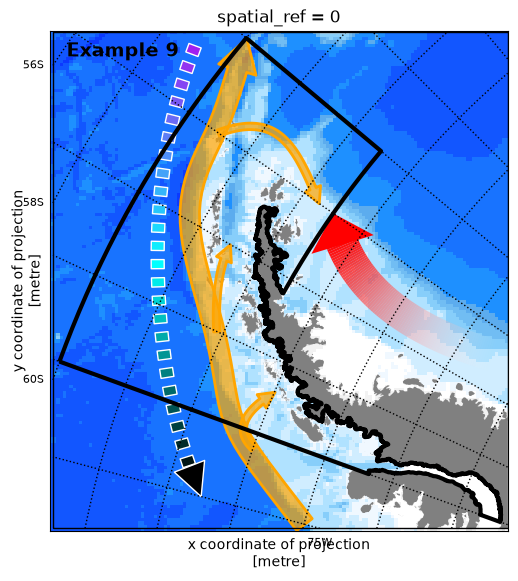

In [18]:
asd_481 = asds[asds["GAR_Short_Label"] == "481"]
bb = asd_481.buffer(20000).total_bounds
bx = box(*bb)
coast_live = cg.load_coastline()
land = coast_live[coast_live["surface"] == "Land"].geometry.union_all()
c481 = land.intersection(bx)
b481 = bathy_small.rio.clip_box(*bb)

arrow1 = cg.create_arrow(
    pd.DataFrame({"lat": [-68, -65, -64, -61, -61, -60], "lon": [-75, -70, -65, -60, -55, -50], "w": [1, 3, 3, 3, 3, 1]}),
    colour="orange", transparency=0.3, pwidth=3, hlength=10, hwidth=6,
)
arrow2 = cg.create_arrow(
    pd.DataFrame({"lat": [-66, -65, -66], "lon": [-71, -70, -67]}),
    colour="orange", transparency=0.3, pwidth=1, hlength=5, hwidth=2.5,
)
arrow3 = cg.create_arrow(
    pd.DataFrame({"lat": [-63.8, -63, -63], "lon": [-65, -62, -60]}),
    colour="orange", transparency=0.3, pwidth=1, hlength=5, hwidth=2.5,
)
arrow4 = cg.create_arrow(
    pd.DataFrame({"lat": [-61, -62, -63, -64.5], "lon": [-55, -52, -53, -55]}),
    colour="orange", transparency=0.3, pwidth=1, hlength=5, hwidth=2.5,
)
arrow5 = cg.create_arrow(
    pd.DataFrame({"lat": [-71, -67, -65], "lon": [-57, -60, -55]}),
    colour=["white", "red"], transparency=[1, 0], pwidth=5, hlength=10, hwidth=10,
    arrow_type="dashed", n_points=100,
)
arrow6 = cg.create_arrow(
    pd.DataFrame({"lat": [-59, -60, -62, -63, -65], "lon": [-52, -60, -65, -70, -75]}),
    colour=["purple", "cyan", "black"], pwidth=2, hlength=10, hwidth=5, arrow_type="dashed", dlength=1,
)

fig, ax = plt.subplots(figsize=(8, 6.5))
cgplot.basemap(ax=ax)
b481.plot(ax=ax, cmap=depth_cmap, norm=depth_norm, add_colorbar=False)
ax.text(bb[0] + 0.03 * (bb[2] - bb[0]), bb[3] - 0.05 * (bb[3] - bb[1]), "Example 9", fontsize=14, fontweight="bold")
gpd_bx = __import__("geopandas").GeoSeries([bx], crs=cg.CCAMLR_CRS)
gpd_bx.boundary.plot(ax=ax, color="black", linewidth=1)
__import__("geopandas").GeoSeries([c481], crs=cg.CCAMLR_CRS).plot(ax=ax, color="grey")
cgplot.add_reference_grid(ax=ax, bounds=bb, res_lat=2, res_lon=5, fontsize=8)
asd_481.boundary.plot(ax=ax, color="black", linewidth=3)
for arrow, edge in [(arrow1, "orange"), (arrow2, "orange"), (arrow3, "orange"), (arrow4, "orange")]:
    arrow.plot(ax=ax, color=list(arrow["col"]), edgecolor=edge, linewidth=2)
arrow5.plot(ax=ax, color=list(arrow5["col"]), edgecolor="none")
arrow6.plot(ax=ax, color=list(arrow6["col"]), edgecolor="white")
plt.show()

Example 10 (path along an isobath):

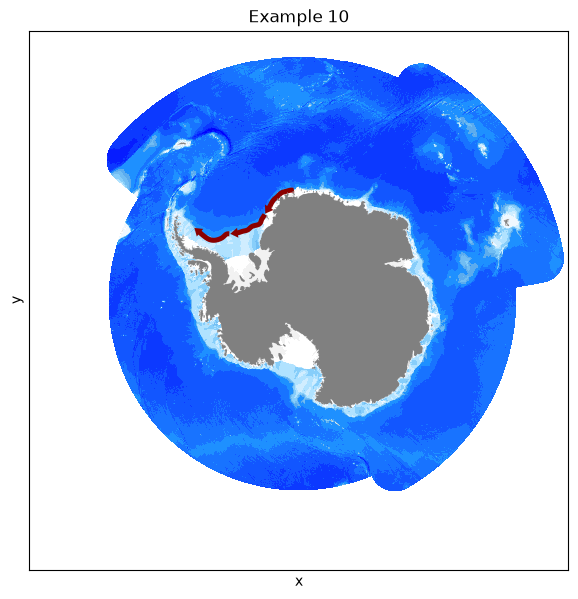

In [19]:
iso = longest_circumpolar_isobath(bathy_small, -1000)
mask = (iso[:, 0] > -2.1e6) & (iso[:, 0] < -0.1e6) & (iso[:, 1] > 0)
iso_c = iso[mask][::-1]  # crop, then go westward
third = len(iso_c) // 3

arr1 = cg.create_arrow(pd.DataFrame({"Y": iso_c[:third, 1], "X": iso_c[:third, 0]}), yx=True)
arr2 = cg.create_arrow(pd.DataFrame({"Y": iso_c[third + 1 : 2 * third, 1], "X": iso_c[third + 1 : 2 * third, 0]}), yx=True)
arr3 = cg.create_arrow(pd.DataFrame({"Y": iso_c[2 * third + 1 :, 1], "X": iso_c[2 * third + 1 :, 0]}), yx=True)

fig, ax = plt.subplots(figsize=(7, 7))
cgplot.basemap(ax=ax, xlim=(-2.5e6, 0.5e6), ylim=(0.25e6, 2.75e6))
bathy_small.plot(ax=ax, cmap=depth_cmap, norm=depth_norm, add_colorbar=False)
arr1.plot(ax=ax, color="darkred")
arr2.plot(ax=ax, color="darkred")
arr3.plot(ax=ax, color="darkred")
coast_all.plot(ax=ax, color="grey")
ax.set_title("Example 10")
plt.show()

## 2.5. Create Hashes

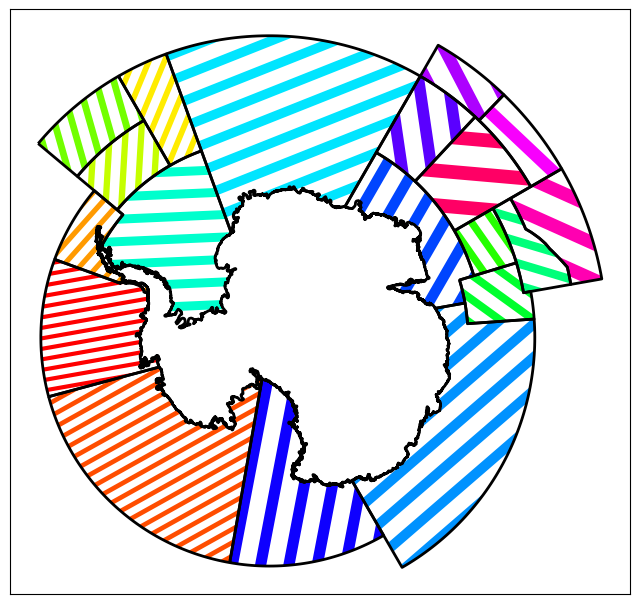

In [20]:
asds_full = cg.load_asds()
n = len(asds_full)
colours_h = plt.cm.hsv(np.linspace(0, 1, n, endpoint=False))
angles = np.linspace(10, 355, n)
spacings = np.linspace(3, 10, n)
widths = np.linspace(3, 10, n)

fig, ax = plt.subplots(figsize=(8, 8))
cgplot.basemap(ax=ax)
asds_full.plot(ax=ax, color="white")
for i in range(n):
    h = cg.create_hashes(asds_full.iloc[[i]], angle=angles[i], spacing=spacings[i], width=widths[i])
    h.plot(ax=ax, color=colours_h[i])
asds_full.boundary.plot(ax=ax, color="black", linewidth=2)
plt.show()

## 2.6. Create Ellipse

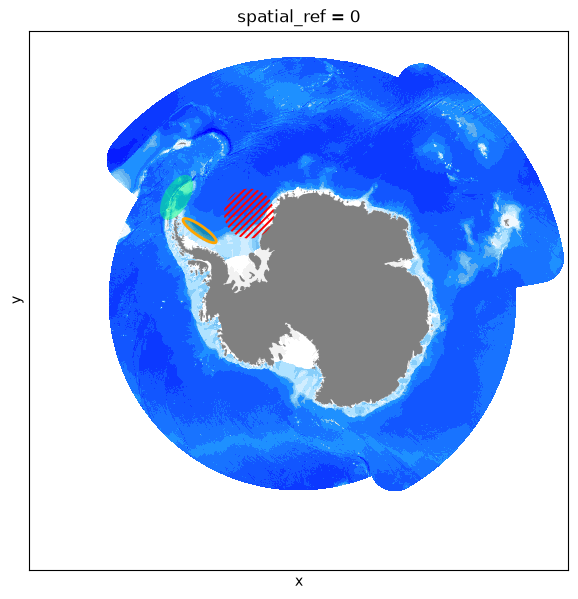

In [21]:
el1 = cg.create_ellipse(latc=-61, lonc=-50, lmaj=500, lmin=250, ang=120)
el2 = cg.create_ellipse(latc=-72, lonc=-30, lmaj=500, lmin=500)
hash_el2 = cg.create_hashes(el2, spacing=2, width=2)
el3 = cg.create_ellipse(latc=-68, lonc=-55, lmaj=400, lmin=100, ang=35)

fig, ax = plt.subplots(figsize=(7, 7))
cgplot.basemap(ax=ax, xlim=(-3e6, 0), ylim=(0, 3e6))
bathy_small.plot(ax=ax, cmap=depth_cmap, norm=depth_norm, add_colorbar=False)
coast_all.plot(ax=ax, color="grey")
el1.plot(ax=ax, color=(0, 1, 0.5, 0.5), linewidth=2)
el3.plot(ax=ax, color=(0, 0.5, 0.5, 0.5), edgecolor="orange", linewidth=2)
hash_el2.plot(ax=ax, color="red", edgecolor="none")
plt.show()

## 2.7. Create Circular Arrow\n\nExamples 1-4:

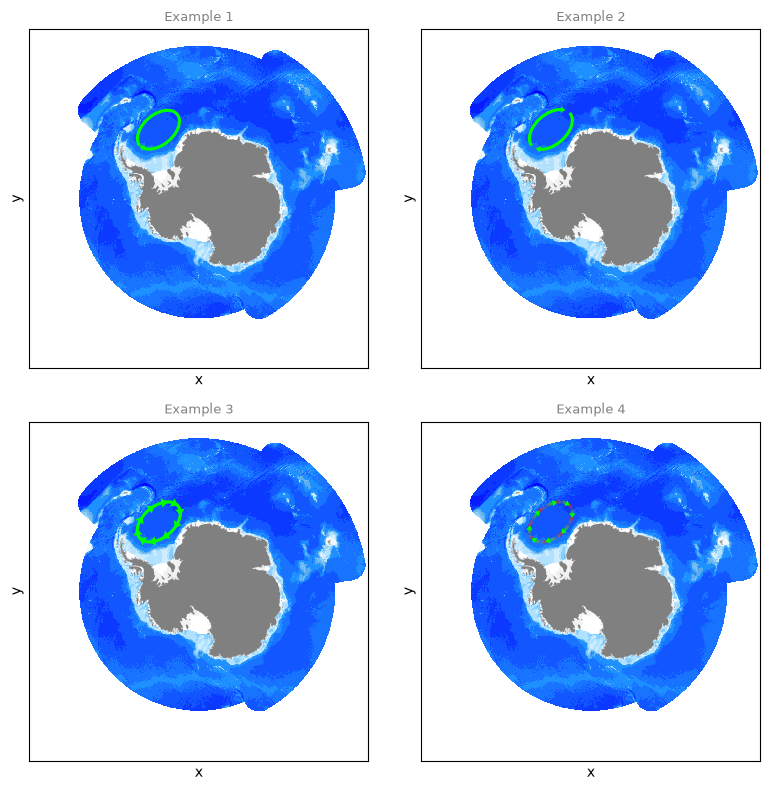

In [22]:
circ_specs = [
    {},
    {"n_arrows": 2, "spacing": 5},
    {"n_arrows": 10, "spacing": -4, "hwidth": 15, "hlength": 20},
    {
        "n_arrows": 8, "spacing": -2, "n_points_arrow": 200,
        "colour": ["red", "orange", "green"], "transparency": [0, 0.9, 0], "arrow_type": "dashed",
    },
]

fig, axes = plt.subplots(2, 2, figsize=(8, 8))
for ax, kwargs, title in zip(axes.flat, circ_specs, [f"Example {i}" for i in range(1, 5)]):
    arrow = cg.create_circular_arrow(**kwargs)
    cgplot.basemap(ax=ax, xlim=(-3e6, 0), ylim=(0, 3e6))
    bathy_small.plot(ax=ax, cmap=depth_cmap, norm=depth_norm, add_colorbar=False)
    coast_all.plot(ax=ax, color="grey")
    arrow.plot(ax=ax, color=list(arrow["col"]), edgecolor="none")
    ax.set_title(title, color="grey", fontsize=9)
fig.tight_layout()
plt.show()

Example 5 (path around two ellipses):

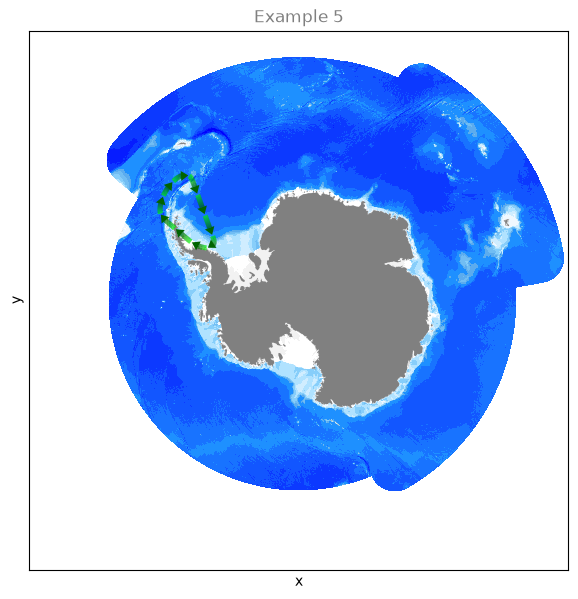

In [23]:
el1b = cg.create_ellipse(latc=-61, lonc=-50, lmaj=500, lmin=250, ang=120)
el2c = cg.create_ellipse(latc=-68, lonc=-57, lmaj=400, lmin=200, ang=35)
merged = el1b.geometry.iloc[0].union(el2c.geometry.iloc[0]).convex_hull
merged = segmentize(merged, max_segment_length=10000)

arrow5 = cg.create_circular_arrow(
    n_arrows=10, spacing=3, n_points_arrow=200, colour=["green", "darkgreen"], arrow_type="dashed", input=merged
)

fig, ax = plt.subplots(figsize=(7, 7))
cgplot.basemap(ax=ax, xlim=(-3e6, 0), ylim=(0, 3e6))
bathy_small.plot(ax=ax, cmap=depth_cmap, norm=depth_norm, add_colorbar=False)
coast_all.plot(ax=ax, color="grey")
arrow5.plot(ax=ax, color=list(arrow5["col"]), edgecolor="none")
ax.set_title("Example 5", color="grey")
plt.show()

Example 6 (path along an isobath):

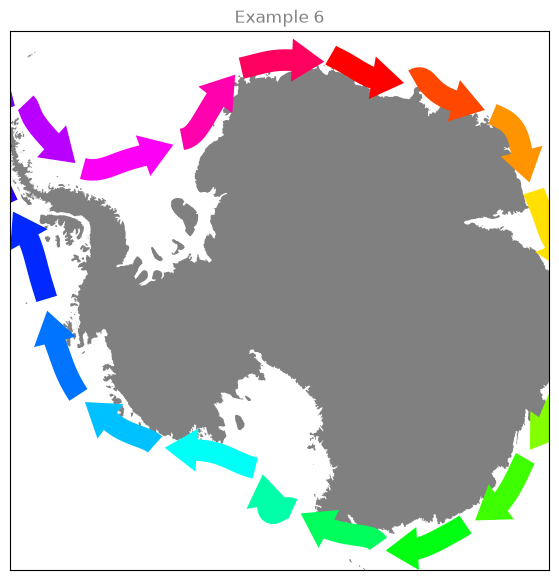

In [24]:
iso_full = longest_circumpolar_isobath(bathy_small, -1000)
idx = np.round(np.linspace(0, len(iso_full) - 1, 200)).astype(int)
iso_poly = Polygon(iso_full[idx])

arrow6 = cg.create_circular_arrow(n_arrows=20, spacing=1, input=iso_poly, pwidth=10, hlength=30, hwidth=20)

fig, ax = plt.subplots(figsize=(7, 7))
cgplot.basemap(ax=ax, xlim=(-2.5e6, 2.5e6), ylim=(-2.5e6, 2.5e6))
coast_all.plot(ax=ax, color="grey")
colours6 = plt.cm.hsv(np.linspace(0, 1, len(arrow6), endpoint=False))
arrow6.plot(ax=ax, color=colours6, edgecolor="none")
ax.set_title("Example 6", color="grey")
plt.show()

# Example 7 in the R README is a GIF animation (10-frame Weddell Sea gyre
# via gifski) rather than a static figure -- out of scope for a notebook
# cell, skipped here.